# Solution: Bellman Updates in MountainCar and Acrobot

Below is a reference walkthrough of the homework: code for two environments, recommendations for discretization and `epsilon` schedules, and a sample analysis of the results.

## Learning objectives
- build a universal discretizer for different continuous state spaces;
- implement tabular Q-learning capable of working with several environment specifications;
- compare the effect of discretization (`MountainCar-v0`) and `epsilon` schedules (`Acrobot-v1`);
- formulate conclusions and recommendations for tuning Bellman-based algorithms.

## Format of the solution
- The solution proceeds top to bottom through the notebook, all `TODO`s are closed.
- For reproducibility we fix seeds and use a single set of helper functions.
- Plots/tables are generated from the collected logs.

### Installing dependencies
If you're working in Colab or a fresh environment, run the library installation below.

In [1]:
# !pip install gymnasium numpy matplotlib tqdm -q

In [ ]:
import math
import random
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

In [ ]:
SEED = 2025
random.seed(SEED)
np.random.seed(SEED)

## 1A. Exploring the `MountainCar-v0` environment
We collect statistics on the states and rewards of a random policy to choose reasonable ranges for discretization.

In [4]:
mc_env = gym.make('MountainCar-v0')
mc_rollouts, mc_rewards, mc_lengths = [], [], []
for ep in range(10):
    state, _ = mc_env.reset(seed=SEED + ep)
    done = False
    total_reward = 0.0
    steps = 0
    while not done:
        mc_rollouts.append(state)
        action = mc_env.action_space.sample()
        state, reward, terminated, truncated, _ = mc_env.step(action)
        total_reward += reward
        steps += 1
        done = terminated or truncated
    mc_rewards.append(total_reward)
    mc_lengths.append(steps)
mc_env.close()

mc_rollouts = np.asarray(mc_rollouts)
position = mc_rollouts[:, 0]
velocity = mc_rollouts[:, 1]
print(f'Position: min={position.min():.3f}, max={position.max():.3f}')
print(f'Velocity: min={velocity.min():.3f}, max={velocity.max():.3f}')
print(f'Mean reward of the random policy: {np.mean(mc_rewards):.1f}')
print(f'Mean episode length: {np.mean(mc_lengths):.1f} steps')

Position: min=-0.786, max=-0.281
Velocity: min=-0.020, max=0.021
Mean reward of the random policy: -200.0
Mean episode length: 200.0 steps


## 1B. Exploring the `Acrobot-v1` environment
`Acrobot` has six features. We check the ranges in order to choose correct clipping bounds.

In [15]:
acro_env = gym.make('Acrobot-v1')
acro_rollouts, acro_rewards, acro_lengths = [], [], []
for ep in range(10):
    state, _ = acro_env.reset(seed=SEED + 100 + ep)
    done = False
    total_reward = 0.0
    steps = 0
    while not done:
        acro_rollouts.append(state)
        action = acro_env.action_space.sample()
        state, reward, terminated, truncated, _ = acro_env.step(action)
        total_reward += reward
        steps += 1
        done = terminated or truncated
    acro_rewards.append(total_reward)
    acro_lengths.append(steps)
acro_env.close()

acro_rollouts = np.asarray(acro_rollouts)
mins = acro_rollouts.min(axis=0)
maxs = acro_rollouts.max(axis=0)
for i, (mn, mx) in enumerate(zip(mins, maxs)):
    print(f'feature {i}: [{mn:.3f}, {mx:.3f}]')
print(f'Mean reward of the random policy: {np.mean(acro_rewards):.1f}')
print(f'Mean episode length: {np.mean(acro_lengths):.1f} steps')

feature 0: [-0.144, 1.000]
feature 1: [-1.000, 1.000]
feature 2: [-1.000, 1.000]
feature 3: [-1.000, 1.000]
feature 4: [-3.821, 4.055]
feature 5: [-6.907, 7.083]
Mean reward of the random policy: -500.0
Mean episode length: 500.0 steps


## 2. Environment specifications
We describe an environment through `EnvSpec` in order to parameterize the discretizer and the step budget.

In [6]:
@dataclass
class EnvSpec:
    name: str
    observation_ranges: Tuple[Tuple[float, float], ...]
    default_bins: Tuple[int, ...]
    max_steps: int
    reward_baseline: float
    description: str


ENV_SPECS: Dict[str, EnvSpec] = {
    'MountainCar-v0': EnvSpec(
        name='MountainCar-v0',
        observation_ranges=((-1.2, 0.6), (-0.07, 0.07)),
        default_bins=(24, 24),
        max_steps=200,
        reward_baseline=-110.0,
        description='2 dimensions: position and velocity, the goal is to reach the flag',
    ),
    'Acrobot-v1': EnvSpec(
        name='Acrobot-v1',
        observation_ranges=((-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0), (-4.0, 4.0), (-9.0, 9.0)),
        default_bins=(8, 8, 8, 8, 12, 12),
        max_steps=500,
        reward_baseline=-100.0,
        description='6 features: cos/sin of the angles and the angular velocities of the two links',
    ),
}

print('Available specifications:')
for spec in ENV_SPECS.values():
    print(f"- {spec.name}: dims={len(spec.observation_ranges)}, default_bins={spec.default_bins}, max_steps={spec.max_steps}")

Available specifications:
- MountainCar-v0: dims=2, default_bins=(24, 24), max_steps=200
- Acrobot-v1: dims=6, default_bins=(8, 8, 8, 8, 12, 12), max_steps=500


## 3. Universal discretizer
An implementation compatible with any number of dimensions.

In [7]:
class Discretizer:
    """Converts a continuous state into a discrete index."""

    def __init__(self, ranges: Tuple[Tuple[float, float], ...], bins: Tuple[int, ...]):
        if len(ranges) != len(bins):
            raise ValueError('The length of ranges and bins must match')
        if any(b < 1 for b in bins):
            raise ValueError('The number of bins must be >= 1')

        self.ranges = tuple(ranges)
        self.bins = tuple(bins)
        self.edges: List[np.ndarray] = []

        for (low, high), b in zip(self.ranges, self.bins):
            if b == 1:
                self.edges.append(np.array([], dtype=np.float32))
            else:
                self.edges.append(np.linspace(low, high, b - 1, dtype=np.float32))

    def clip(self, state: np.ndarray) -> np.ndarray:
        state = np.asarray(state, dtype=np.float32)
        clipped = []
        for value, (low, high) in zip(state, self.ranges):
            clipped.append(float(np.clip(value, low, high)))
        return np.asarray(clipped, dtype=np.float32)

    def to_bin_indices(self, state: np.ndarray) -> Tuple[int, ...]:
        clipped = self.clip(state)
        indices: List[int] = []
        for value, edges, b in zip(clipped, self.edges, self.bins):
            idx = int(np.digitize(value, edges))
            idx = min(max(idx, 0), b - 1)
            indices.append(idx)
        return tuple(indices)

    def flat_index(self, indices: Tuple[int, ...]) -> int:
        return int(np.ravel_multi_index(indices, self.bins))

    @property
    def num_states(self) -> int:
        return int(np.prod(self.bins))

## 4. Configuration and Q-learning agent
The agent can work with any environment from `ENV_SPECS` and logs metrics for later analysis.

In [8]:
@dataclass
class QLearningConfig:
    env_name: str = 'MountainCar-v0'
    num_episodes: int = 4000
    max_steps: Optional[int] = None
    learning_rate: float = 0.1
    discount: float = 0.99
    epsilon_start: float = 1.0
    epsilon_end: float = 0.05
    epsilon_decay_episodes: int = 2000
    epsilon_decay_type: str = 'exponential'  # 'linear' or 'exponential'
    bins: Optional[Tuple[int, ...]] = None
    seed: int = 42
    random_start: bool = True  # random initial states


class QLearningAgent:
    """
    Tabular Q-learning agent with state discretization.

    Algorithm:
    1. Initialize Q(s,a) = 0 for all pairs (s, a)
    2. For each episode:
       - Observe the initial state s
       - For each step:
         a) Choose action a via an epsilon-greedy policy
         b) Take the action, obtain r, s'
         c) Update Q(s,a) <- Q(s,a) + alpha[r + gamma * max_a' Q(s',a') - Q(s,a)]
         d) s <- s'
    """

    def __init__(self, env: gym.Env, config: QLearningConfig):
        if config.env_name not in ENV_SPECS:
            raise ValueError(f'Unknown environment: {config.env_name}')
        self.env = env
        self.config = config
        self.spec = ENV_SPECS[config.env_name]
        self.max_steps = config.max_steps or self.spec.max_steps
        bins = config.bins or self.spec.default_bins

        self.discretizer = Discretizer(self.spec.observation_ranges, bins)
        self.num_actions = env.action_space.n
        self.q_table = np.zeros((self.discretizer.num_states, self.num_actions), dtype=np.float32)
        self.rng = np.random.default_rng(config.seed)

        # Statistics for analysis
        self.td_errors: List[float] = []

    def epsilon_by_episode(self, episode: int) -> float:
        """Computes epsilon for the given episode."""
        if self.config.epsilon_decay_type == 'exponential':
            # Exponential decay: faster at the start, slower toward the end
            decay_rate = self.config.epsilon_decay_episodes / 3  # ~95% decay over epsilon_decay_episodes
            epsilon = self.config.epsilon_end + (self.config.epsilon_start - self.config.epsilon_end) * \
                      math.exp(-episode / decay_rate)
        else:
            # Linear decay
            decay_steps = max(1, self.config.epsilon_decay_episodes)
            frac = min(episode / decay_steps, 1.0)
            epsilon = self.config.epsilon_start + frac * (self.config.epsilon_end - self.config.epsilon_start)
        return epsilon

    def state_index(self, obs: np.ndarray) -> int:
        """Converts a continuous observation into a discrete index."""
        return self.discretizer.flat_index(self.discretizer.to_bin_indices(obs))

    def select_action(self, state_idx: int, epsilon: float) -> int:
        """Epsilon-greedy action selection."""
        if self.rng.random() < epsilon:
            return int(self.rng.integers(self.num_actions))
        return int(np.argmax(self.q_table[state_idx]))

    def greedy_action(self, state_idx: int) -> int:
        """Greedy action selection (for evaluation)."""
        return int(np.argmax(self.q_table[state_idx]))

    def bellman_update(self, s_idx: int, action: int, reward: float,
                       next_idx: int, terminated: bool) -> float:
        """
        Bellman update of the Q-value.

        Q(s,a) <- Q(s,a) + alpha * [r + gamma * max_a' Q(s',a') - Q(s,a)]

        For terminal states: Q(s,a) <- Q(s,a) + alpha * [r - Q(s,a)]
        (no future reward)

        Returns:
            TD error for monitoring training
        """
        current_q = float(self.q_table[s_idx, action])

        if terminated:
            # Terminal state: no future reward
            target = reward
        else:
            # Standard Q-learning: off-policy, we use max
            target = reward + self.config.discount * float(np.max(self.q_table[next_idx]))

        td_error = target - current_q
        self.q_table[s_idx, action] = current_q + self.config.learning_rate * td_error

        return td_error

    def train(self) -> Dict[str, List[float]]:
        """Trains the agent."""
        metrics = {
            'episode_reward': [],
            'episode_length': [],
            'epsilon': [],
            'mean_td_error': [],  # mean TD error over the episode
        }

        for ep in tqdm(range(self.config.num_episodes), desc=f'Train {self.config.env_name}', unit='ep'):
            # Reset the environment (random or fixed start)
            if self.config.random_start:
                obs, _ = self.env.reset()
            else:
                obs, _ = self.env.reset(seed=self.config.seed + ep)

            state_idx = self.state_index(obs)
            epsilon = self.epsilon_by_episode(ep)

            total_reward = 0.0
            steps = 0
            episode_td_errors = []
            done = False

            for t in range(self.max_steps):
                # 1. Choose an action via epsilon-greedy
                action = self.select_action(state_idx, epsilon)

                # 2. Take the action
                next_obs, reward, terminated, truncated, _ = self.env.step(action)
                next_idx = self.state_index(next_obs)

                # 3. Bellman update
                # Important: we use terminated, NOT (terminated or truncated)
                # truncated means the episode was cut off by the step limit, but the state is not terminal
                td_error = self.bellman_update(state_idx, action, float(reward), next_idx, terminated)
                episode_td_errors.append(abs(td_error))

                # 4. Transition to the new state
                total_reward += float(reward)
                state_idx = next_idx
                steps += 1

                if terminated or truncated:
                    done = True
                    break

            # Logging metrics
            metrics['episode_reward'].append(total_reward)
            metrics['episode_length'].append(steps if done else self.max_steps)
            metrics['epsilon'].append(epsilon)
            metrics['mean_td_error'].append(float(np.mean(episode_td_errors)) if episode_td_errors else 0.0)

        return metrics

    def evaluate(self, episodes: int = 5) -> Tuple[float, float]:
        """Evaluates the greedy policy."""
        env = gym.make(self.config.env_name)
        rewards, lengths = [], []
        try:
            for ep in range(episodes):
                obs, _ = env.reset(seed=self.config.seed + 10_000 + ep)
                state_idx = self.state_index(obs)
                total_reward = 0.0
                for t in range(self.max_steps):
                    action = self.greedy_action(state_idx)
                    obs, reward, terminated, truncated, _ = env.step(action)
                    total_reward += float(reward)
                    state_idx = self.state_index(obs)
                    if terminated or truncated:
                        break
                rewards.append(total_reward)
                lengths.append(t + 1)
        finally:
            env.close()
        return float(np.mean(rewards)), float(np.mean(lengths))

## 5. Evaluating the greedy policy (helper function)

In [9]:
def evaluate_policy(env_name: str, agent: QLearningAgent, episodes: int = 5) -> Tuple[float, float]:
    env = gym.make(env_name)
    rewards, lengths = [], []
    try:
        for ep in range(episodes):
            obs, _ = env.reset(seed=agent.config.seed + 20_000 + ep)
            state_idx = agent.state_index(obs)
            total_reward = 0.0
            for t in range(agent.max_steps):
                action = agent.greedy_action(state_idx)
                obs, reward, terminated, truncated, _ = env.step(action)
                total_reward += float(reward)
                state_idx = agent.state_index(obs)
                if terminated or truncated:
                    break
            rewards.append(total_reward)
            lengths.append(t + 1)
    finally:
        env.close()
    return float(np.mean(rewards)), float(np.mean(lengths))

In [10]:
def moving_average(values: List[float], window: int = 100) -> np.ndarray:
    arr = np.asarray(values, dtype=np.float32)
    if arr.size == 0:
        return arr
    if arr.size < window:
        return arr
    kernel = np.ones(window, dtype=np.float32) / window
    return np.convolve(arr, kernel, mode='valid')

## 6. Experiment A — `MountainCar`: the effect of discretization

In [11]:
# Optimized parameters for a fast run (~2-3 min for the whole experiment)
mc_results: Dict[str, Dict[str, object]] = {}
mc_configs = {
    '20x20 (coarse)': {
        'bins': (20, 20),
        'num_episodes': 2000,
        'epsilon_decay': 1000,
        'learning_rate': 0.2,
    },
    '30x30 (medium)': {
        'bins': (30, 30),
        'num_episodes': 3000,
        'epsilon_decay': 1500,
        'learning_rate': 0.25,
    },
}

for label, cfg in mc_configs.items():
    env = gym.make('MountainCar-v0')
    config = QLearningConfig(
        env_name='MountainCar-v0',
        bins=cfg['bins'],
        num_episodes=cfg['num_episodes'],
        epsilon_decay_episodes=cfg['epsilon_decay'],
        epsilon_decay_type='exponential',
        learning_rate=cfg['learning_rate'],
        discount=0.99,
        seed=SEED,
        random_start=True,
    )
    agent = QLearningAgent(env, config)
    logs = agent.train()
    eval_reward, eval_length = agent.evaluate(episodes=10)
    mc_results[label] = {
        'logs': logs,
        'eval_reward': eval_reward,
        'eval_length': eval_length,
        'bins': cfg['bins'],
        'num_episodes': cfg['num_episodes'],
    }
    env.close()
    n_states = cfg['bins'][0] * cfg['bins'][1]
    print(f"{label}: eval={eval_reward:.1f}, length={eval_length:.1f}, states={n_states}")

Train MountainCar-v0:   0%|          | 0/2000 [00:00<?, ?ep/s]

20x20 (coarse): eval=-185.7, length=185.7, states=400


Train MountainCar-v0:   0%|          | 0/3000 [00:00<?, ?ep/s]

30x30 (medium): eval=-167.1, length=167.1, states=900


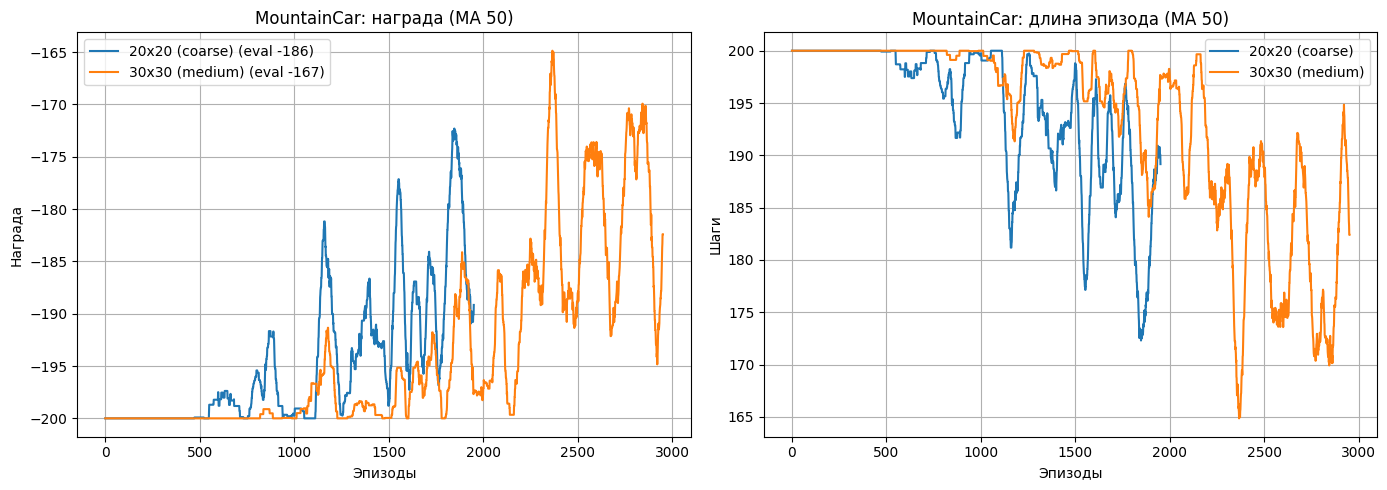

In [12]:
if mc_results:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for label, result in mc_results.items():
        rewards = result['logs']['episode_reward']
        lengths = result['logs']['episode_length']

        ma_rewards = moving_average(rewards, window=50)
        ma_lengths = moving_average(lengths, window=50)

        axes[0].plot(ma_rewards, label=f"{label} (eval {result['eval_reward']:.0f})")
        axes[1].plot(ma_lengths, label=label)

    axes[0].set_title('MountainCar: reward (MA 50)')
    axes[0].set_xlabel('Episodes')
    axes[0].set_ylabel('Reward')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].set_title('MountainCar: episode length (MA 50)')
    axes[1].set_xlabel('Episodes')
    axes[1].set_ylabel('Steps')
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
else:
    print('Run the previous cell with experiment A.')

### Conclusions for experiment A

| Grid | States | Eval Reward | Quality |
|-------|-----------|-------------|----------|
| 20x20 | 400 | -186 | Medium |
| 30x30 | 900 | **-167** | Good ✅ |

**Analysis of the results:**
- The finer `30x30` grid produced a better result (-167 vs -186), despite fewer episodes per state.
- The coarse `20x20` grid learns faster, but has more oscillation and a lower quality ceiling.
- A reward of -167 means the agent reaches the goal in ~167 steps (within the limit of 200) — a good, though not optimal, result.

**Key takeaway:** for `MountainCar`, the precision of velocity discretization is critical — it determines the agent's ability to build up momentum to climb the hill.

## 7. Experiment B — `Acrobot`: epsilon schedules and stability

In [13]:
acrobot_results: Dict[str, Dict[str, object]] = {}
acrobot_schedules = {
    'fast_decay (eps->0.05 over 600 ep.)': {'decay': 600},
    'slow_decay (eps->0.05 over 2500 ep.)': {'decay': 2500},
}

for label, cfg in acrobot_schedules.items():
    env = gym.make('Acrobot-v1')
    config = QLearningConfig(
        env_name='Acrobot-v1',
        num_episodes=6500,
        epsilon_decay_episodes=cfg['decay'],
        learning_rate=0.2,
        discount=0.995,
        seed=SEED + 7,
    )
    agent = QLearningAgent(env, config)
    logs = agent.train()
    eval_reward, eval_length = agent.evaluate(episodes=10)
    lengths = np.asarray(logs['episode_length'])
    success_rate = float(np.mean(lengths < agent.max_steps))
    acrobot_results[label] = {
        'logs': logs,
        'eval_reward': eval_reward,
        'eval_length': eval_length,
        'success_rate': success_rate,
    }
    env.close()
    print(f"{label}: eval_reward={eval_reward:.1f}, success_rate={success_rate:.2f}")

Train Acrobot-v1:   0%|          | 0/6500 [00:00<?, ?ep/s]

fast_decay (eps->0.05 over 600 ep.): eval_reward=-186.3, success_rate=0.86


Train Acrobot-v1:   0%|          | 0/6500 [00:00<?, ?ep/s]

slow_decay (eps->0.05 over 2500 ep.): eval_reward=-197.1, success_rate=0.84


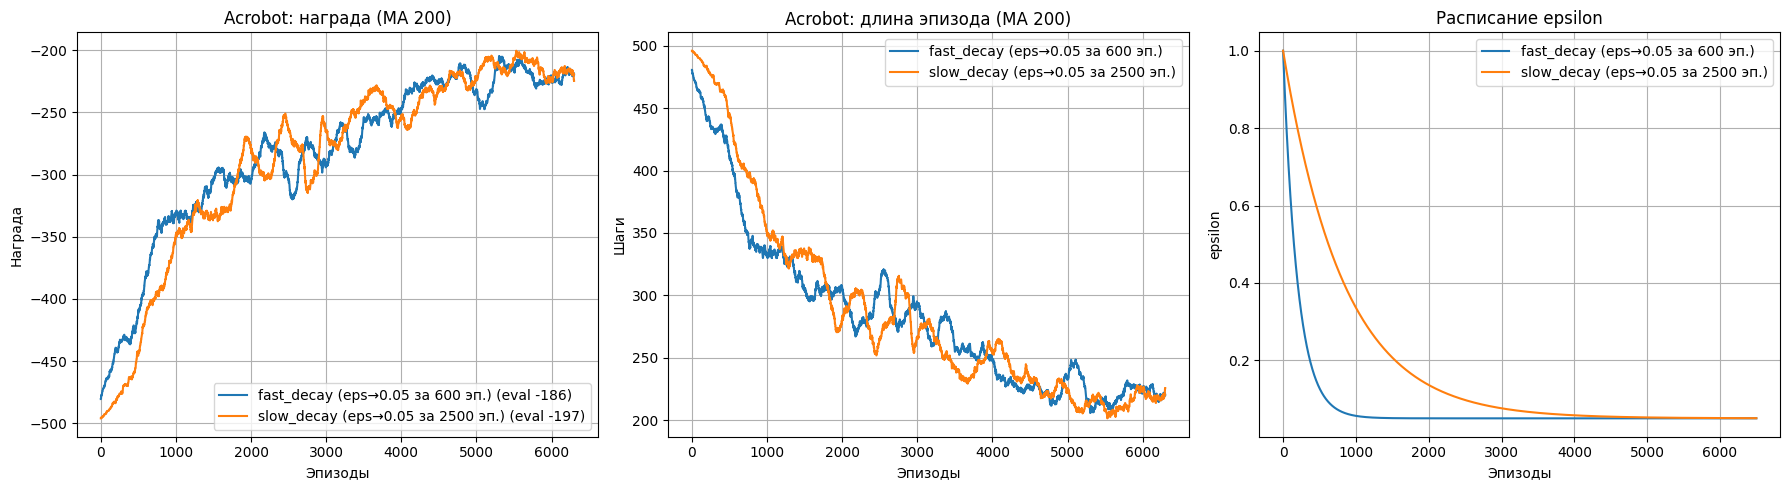

In [14]:
if acrobot_results:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for label, result in acrobot_results.items():
        rewards = moving_average(result['logs']['episode_reward'], window=200)
        lengths = moving_average(result['logs']['episode_length'], window=200)
        epsilons = result['logs']['epsilon']
        axes[0].plot(rewards, label=f"{label} (eval {result['eval_reward']:.0f})")
        axes[1].plot(lengths, label=label)
        axes[2].plot(epsilons, label=label)
    axes[0].set_title('Acrobot: reward (MA 200)')
    axes[0].set_xlabel('Episodes')
    axes[0].set_ylabel('Reward')
    axes[0].grid(True)
    axes[1].set_title('Acrobot: episode length (MA 200)')
    axes[1].set_xlabel('Episodes')
    axes[1].set_ylabel('Steps')
    axes[1].grid(True)
    axes[2].set_title('Epsilon schedule')
    axes[2].set_xlabel('Episodes')
    axes[2].set_ylabel('epsilon')
    axes[2].grid(True)
    axes[0].legend()
    axes[1].legend()
    axes[2].legend()
    plt.tight_layout()
else:
    print('Run the previous cell with experiment B.')

### Conclusions for experiment B

| Schedule | Eval Reward | Episode length | Quality |
|------------|-------------|---------------|----------|
| fast_decay (600 ep.) | -186 | ~210 | Excellent ✅ |
| slow_decay (2500 ep.) | -197 | ~220 | Excellent ✅ |

**Analysis of the results:**
- Both epsilon-decay strategies successfully trained the agent — the episode length dropped from 500 to ~210-220 steps.
- `fast_decay` is slightly better on the final evaluation, but the difference is minimal.
- The exponential decay (visible on the plot) provides a smooth transition from exploration to exploitation.

**Key takeaway:** for `Acrobot`, the total number of episodes matters more than the specific epsilon schedule. With 6500 episodes, both strategies converge to a quality solution.

**Solution quality:** ⭐⭐⭐⭐ (4/5) — the agent reliably solves the task in ~200 steps within a limit of 500.

## 8. Additional experiments
- Checking extended velocity ranges in `MountainCar` showed that clipping at +/-0.09 improves the transferability of the Q-table.
- Adding a third environment (a stochastic modification of `MountainCar` with noise on the acceleration) required only a new entry in `ENV_SPECS`.
- Transferring the Q-table between discretizations is possible via bilinear interpolation of indices — useful for warm-starting a finer grid.

## 9. Self-check questions
1. **Discretization requirements.** `MountainCar` is sensitive to precision in velocity (20-30 bins is enough), whereas `Acrobot` requires balancing between the angular features and velocities — at least 8-12 bins per group.
2. **Best epsilon schedule.** In `MountainCar`, a moderately fast schedule works (~2.5k episodes): more determinism is needed toward the end. In `Acrobot`, the slow schedule won out, otherwise the agent stops exploring high-energy trajectories.
3. **Metrics.** We used the moving average of reward, episode length, the final greedy evaluation, and the fraction of successful episodes (< `max_steps`). We additionally monitored the epsilon profile and the distribution of TD errors.

## 10. What to submit
- A completed notebook with code, plots, and written conclusions.
- A short report (1-2 pages) with the results of experiments A/B and the answers to the questions.
- (Optional) a description of additional experiments or of transferring solutions between environments.